# Episode 4 — One-hot encoding demystified

**Goal:** show that one-hot encoding is a **geometric** choice, not a syntactic one — it turns every category into a canonical basis vector, erasing any similarity structure between categories. Then show the three ways this bites you at scale: memory, per-category weight noise, and the `handle_unknown` production bug. Then hand the baton to embeddings (Episode 18).

Follows on from Episode 1 ("a feature is a coordinate axis") and Episode 3 (the "hard → soft → learned" axis). This episode is the *problem statement* that Episodes 5, 13, and 18 answer.


## Setup

Same `.venv` as episodes 1–3.


In [1]:
import sys
import importlib.metadata as md

print(f'python executable: {sys.executable}')
print()
for pkg in ('numpy', 'pandas', 'scikit-learn', 'matplotlib', 'scipy'):
    try:
        print(f'  {pkg:14s} {md.version(pkg)}')
    except md.PackageNotFoundError:
        print(f'  {pkg:14s} NOT INSTALLED  <- run: pip install -r requirements.txt')

print()
print('OK: .venv is active' if '.venv' in sys.executable else 'WARNING: not in .venv')


python executable: /Users/akumarmarati/Desktop/manil2020/dimensionality_reduction/.venv/bin/python3

  numpy          2.0.2
  pandas         2.3.3
  scikit-learn   1.6.1
  matplotlib     3.9.4
  scipy          1.13.1

OK: .venv is active


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import sparse
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import pairwise_distances
from sklearn.pipeline import Pipeline

RNG = 0
rng = np.random.default_rng(RNG)
np.set_printoptions(precision=3, suppress=True)


## Part 1 — What one-hot actually does (geometry)

Textbook: *"convert a categorical column with K unique values into K binary columns."*

Geometric restatement: **every category becomes a canonical basis vector of $\mathbb{R}^K$.**

- Toyota → $(1, 0, 0)$
- Honda  → $(0, 1, 0)$
- Ferrari → $(0, 0, 1)$

Three points, all at unit distance from the origin, all mutually perpendicular. Let's prove it.


In [3]:
brands = ['Toyota', 'Honda', 'Ferrari']
X = np.eye(3)  # one-hot for three categories
print('one-hot matrix (rows = categories):')
print(X)

print()
print('pairwise Euclidean distances:')
D = pairwise_distances(X)
print(pd.DataFrame(D, index=brands, columns=brands).round(3))

print()
print('pairwise cosine similarities (off-diagonal):')
# cosine similarity = dot / (||a|| * ||b||); for unit vectors it's just the dot product
cos = X @ X.T
print(pd.DataFrame(cos, index=brands, columns=brands).round(3))


one-hot matrix (rows = categories):
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]

pairwise Euclidean distances:
         Toyota  Honda  Ferrari
Toyota    0.000  1.414    1.414
Honda     1.414  0.000    1.414
Ferrari   1.414  1.414    0.000

pairwise cosine similarities (off-diagonal):
         Toyota  Honda  Ferrari
Toyota      1.0    0.0      0.0
Honda       0.0    1.0      0.0
Ferrari     0.0    0.0      1.0


Every off-diagonal Euclidean distance is exactly $\sqrt{2} \approx 1.414$. Every off-diagonal cosine similarity is exactly $0$.

**Toyota–Honda distance equals Toyota–Ferrari distance.** The encoding is not lossy in the information-theory sense — you can perfectly recover which category each row came from — but it is **structure-erasing**. The prior "Toyota is more like Honda than Ferrari" was in your head. It never made it into the matrix.

### Contrast: a hand-made 2D embedding

Now the same three brands, but encoded as points in $\mathbb{R}^2$ where I've hand-placed them to reflect similarity. This is the kind of thing a *learned* embedding (Ep. 18) will produce automatically — for now we're just showing that the encoding *can* carry similarity if we let it.


In [4]:
emb = np.array([
    [ 0.8, 0.6],   # Toyota
    [ 0.7, 0.7],   # Honda
    [-0.5, 0.5],   # Ferrari
])

D_emb = pairwise_distances(emb)
print('embedding pairwise distances:')
print(pd.DataFrame(D_emb, index=brands, columns=brands).round(3))


embedding pairwise distances:
         Toyota  Honda  Ferrari
Toyota    0.000  0.141    1.304
Honda     0.141  0.000    1.217
Ferrari   1.304  1.217    0.000


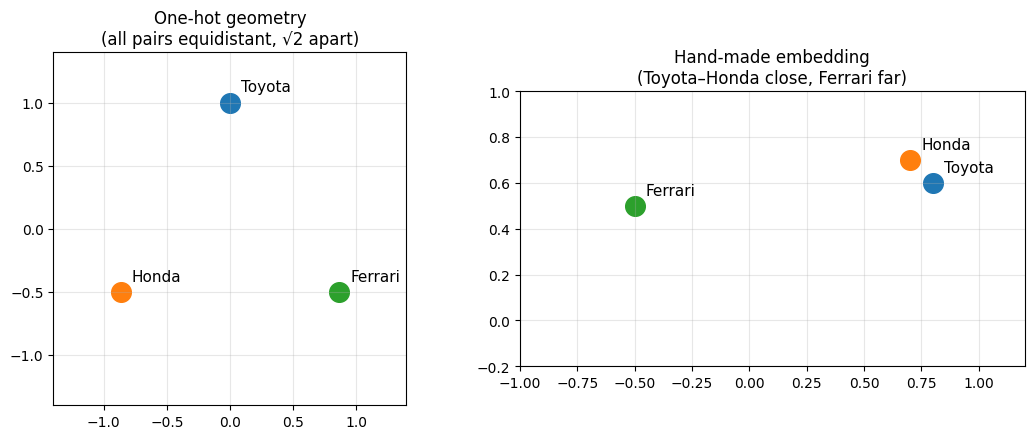

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# One-hot: project the three 3D basis vectors onto the plane orthogonal to (1,1,1),
# which is where they're equidistant. Any 2D view suffices — the point is symmetry.
theta = np.array([np.pi/2, np.pi/2 + 2*np.pi/3, np.pi/2 + 4*np.pi/3])
onehot_2d = np.column_stack([np.cos(theta), np.sin(theta)])

for name, (x, y) in zip(brands, onehot_2d):
    axes[0].scatter(x, y, s=200)
    axes[0].annotate(name, (x, y), textcoords="offset points", xytext=(8, 8), fontsize=11)
axes[0].set_title('One-hot geometry\n(all pairs equidistant, √2 apart)')
axes[0].set_aspect('equal')
axes[0].grid(alpha=0.3)
axes[0].set_xlim(-1.4, 1.4); axes[0].set_ylim(-1.4, 1.4)

for name, (x, y) in zip(brands, emb):
    axes[1].scatter(x, y, s=200)
    axes[1].annotate(name, (x, y), textcoords="offset points", xytext=(8, 8), fontsize=11)
axes[1].set_title('Hand-made embedding\n(Toyota–Honda close, Ferrari far)')
axes[1].set_aspect('equal')
axes[1].grid(alpha=0.3)
axes[1].set_xlim(-1.0, 1.2); axes[1].set_ylim(-0.2, 1.0)

plt.tight_layout()
plt.show()


Same three brands. Two encodings. Two geometries.

- Left: all pairs at $\sqrt{2}$. No similarity information.
- Right: Toyota–Honda are ~10× closer to each other than either is to Ferrari.

**Key sentence:** one-hot's mutual orthogonality is not a bug — it's the encoding's entire semantic content, and that content is *"I refuse to tell the model anything about how these categories relate."*

Everything after Ep. 18 in this series is a story about how to *learn* the right-hand encoding from data instead of hand-crafting it.


## Part 2 — Memory catastrophe at high cardinality

Ad-tech-style dataset: many rows, one column of `user_id`, tens of thousands of unique users. What does naïve dense one-hot cost?


In [6]:
def dense_gb(n_rows, n_cats, bytes_per=8):
    return n_rows * n_cats * bytes_per / 1e9

for n_rows in (100_000, 1_000_000, 2_000_000):
    for n_cats in (1_000, 10_000, 50_000):
        gb = dense_gb(n_rows, n_cats)
        print(f'  {n_rows:>10,d} rows × {n_cats:>7,d} categories = {gb:>10,.1f} GB dense')


     100,000 rows ×   1,000 categories =        0.8 GB dense
     100,000 rows ×  10,000 categories =        8.0 GB dense
     100,000 rows ×  50,000 categories =       40.0 GB dense
   1,000,000 rows ×   1,000 categories =        8.0 GB dense
   1,000,000 rows ×  10,000 categories =       80.0 GB dense
   1,000,000 rows ×  50,000 categories =      400.0 GB dense
   2,000,000 rows ×   1,000 categories =       16.0 GB dense
   2,000,000 rows ×  10,000 categories =      160.0 GB dense
   2,000,000 rows ×  50,000 categories =      800.0 GB dense


**Two million rows × fifty thousand categories = 800 GB.** For one column.

Let's actually try it — but on a smaller version so the kernel survives to tell us it failed.


In [7]:
# Smaller scale so we can safely observe the failure
N_ROWS = 100_000
N_CATS = 50_000

user_ids = rng.integers(0, N_CATS, size=N_ROWS).reshape(-1, 1)
df = pd.DataFrame({'user_id': user_ids.ravel().astype(str)})

print(f'rows: {N_ROWS:,}, unique categories: {df.user_id.nunique():,}')
print(f'projected dense size: {dense_gb(N_ROWS, N_CATS):.1f} GB')


rows: 100,000, unique categories: 43,208
projected dense size: 40.0 GB


In [8]:
# The wrong way: dense one-hot.
enc_dense = OneHotEncoder(sparse_output=False, handle_unknown='ignore', dtype=np.float32)

try:
    X_dense = enc_dense.fit_transform(df[['user_id']])
    print(f'dense shape: {X_dense.shape}, actual bytes: {X_dense.nbytes / 1e9:.2f} GB')
except (MemoryError, ValueError) as e:
    print(f'dense allocation failed: {type(e).__name__}: {e}')


dense shape: (100000, 43208), actual bytes: 17.28 GB


In [9]:
# The right way: sparse one-hot (sklearn's default).
enc_sparse = OneHotEncoder(sparse_output=True, handle_unknown='ignore', dtype=np.float32)
X_sparse = enc_sparse.fit_transform(df[['user_id']])

nnz = X_sparse.nnz
sparse_bytes = X_sparse.data.nbytes + X_sparse.indices.nbytes + X_sparse.indptr.nbytes
dense_bytes = N_ROWS * X_sparse.shape[1] * 4  # float32

print(f'sparse matrix shape       : {X_sparse.shape}')
print(f'non-zeros                 : {nnz:,}  (== one per row, by construction of one-hot)')
print(f'sparse storage            : {sparse_bytes / 1e6:>10,.2f} MB')
print(f'dense equivalent (float32): {dense_bytes / 1e9:>10,.2f} GB')
print(f'compression ratio         : {dense_bytes / sparse_bytes:>10,.0f}×')


sparse matrix shape       : (100000, 43208)
non-zeros                 : 100,000  (== one per row, by construction of one-hot)
sparse storage            :       1.20 MB
dense equivalent (float32):      17.28 GB
compression ratio         :     14,403×


A one-hot matrix has **exactly one non-zero per row.** The rest of the entries are structurally zero. Sparse formats (CSR / CSC) store only the non-zeros and their column indices — three orders of magnitude less memory in this case, and the ratio grows linearly with cardinality.

**Rule:** dense storage of one-hot at scale is not a memory constraint, it's a category error. Modern sklearn defaults to `sparse_output=True` for exactly this reason.

**Forward hook (Ep. 13):** this is why **truncated SVD**, not PCA, is the linear dimensionality reduction of choice for high-cardinality one-hot. PCA needs to center the matrix (subtract column means), and centering destroys sparsity — every structural zero becomes a small non-zero, and the matrix blows back up to dense. Truncated SVD skips centering and stays sparse throughout.


## Part 3 — The silent kill: rare-category weights are pure noise

Memory is the *loud* failure. Here's the quiet one — the one that ships to production.

One-hot forces the model to learn an **independent weight per category.** Categories cannot share evidence. What happens when a category has only a handful of samples?

Setup: 100 categories with a Zipf sample distribution (a few common, a long tail with 2–5 samples). Real label depends on a category-cluster effect, so *the true weight per category* is small but non-zero. We fit a plain (unregularized) logistic regression and look at the per-category weights.


In [10]:
N_CATS = 100
N_ROWS = 5_000

# Zipf-distributed category IDs — a few common, most rare.
probs = 1.0 / np.arange(1, N_CATS + 1)
probs /= probs.sum()
cat_ids = rng.choice(N_CATS, size=N_ROWS, p=probs)

# True effect per category: small, drawn once.
true_weights = rng.normal(0, 0.5, size=N_CATS)

# Label from a logistic model on the per-row true weight.
logits = true_weights[cat_ids] + rng.normal(0, 1.0, size=N_ROWS)
y = (logits > 0).astype(int)

df3 = pd.DataFrame({'cat': cat_ids.astype(str)})

counts = pd.Series(cat_ids).value_counts().sort_index()
print(f'sample-count distribution across {N_CATS} categories:')
print(f'  min : {counts.min():>4d}')
print(f'  p10 : {int(counts.quantile(0.10)):>4d}')
print(f'  p50 : {int(counts.quantile(0.50)):>4d}')
print(f'  p90 : {int(counts.quantile(0.90)):>4d}')
print(f'  max : {counts.max():>4d}')


sample-count distribution across 100 categories:
  min :    7
  p10 :   10
  p50 :   20
  p90 :   91
  max :  950


/Users/akumarmarati/Desktop/manil2020/dimensionality_reduction/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/akumarmarati/Desktop/manil2020/dimensionality_reduction/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/akumarmarati/Desktop/manil2020/dimensionality_reduction/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/akumarmarati/Desktop/manil2020/dimensionality_reduction/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/akumarmarati/Desktop/manil2020/d

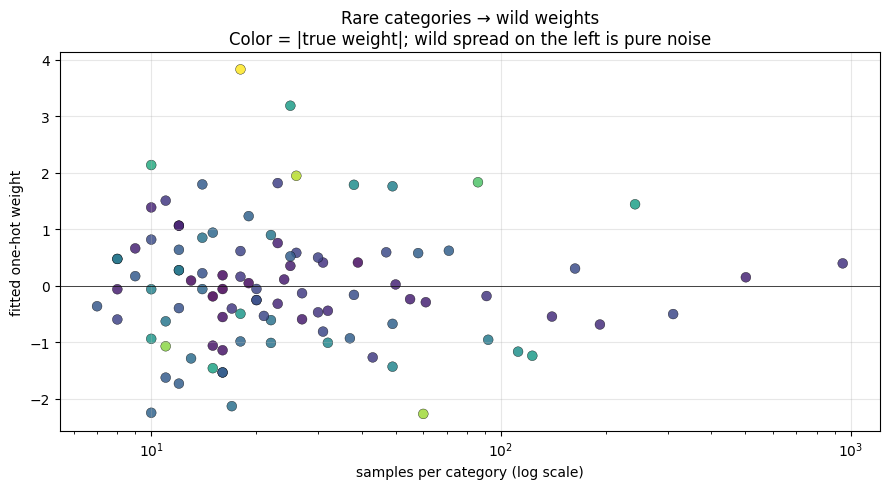

In [11]:
enc = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
X3 = enc.fit_transform(df3[['cat']])

# Unregularized-ish logistic regression — huge C, no penalty in effect.
model = LogisticRegression(C=1e6, max_iter=5000, solver='lbfgs')
model.fit(X3, y)

# Map fitted weights back to categories.
learned_cats = enc.categories_[0].astype(int)
weights = model.coef_.ravel()

fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(counts.reindex(learned_cats).values, weights,
           c=np.abs(true_weights[learned_cats]), cmap='viridis',
           alpha=0.85, s=50, edgecolor='k', linewidth=0.3)
ax.axhline(0, color='k', lw=0.5)
ax.set_xscale('log')
ax.set_xlabel('samples per category (log scale)')
ax.set_ylabel('fitted one-hot weight')
ax.set_title('Rare categories → wild weights\nColor = |true weight|; wild spread on the left is pure noise')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


Common categories (right side of the plot) get weights close to their true effect — modest, low variance. Rare categories (left side) get weights **scattered across an order of magnitude**, much larger than any true effect. That is not the model failing. That is the model doing exactly what you asked: fitting a free parameter from three samples of evidence.

Let's confirm the variance-vs-sample-count scaling with a bootstrap.


In [12]:
n_boot = 40
weight_samples = np.full((n_boot, N_CATS), np.nan)

for b in range(n_boot):
    idx = rng.integers(0, N_ROWS, size=N_ROWS)  # bootstrap resample
    df_b = df3.iloc[idx]
    y_b = y[idx]
    enc_b = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
    X_b = enc_b.fit_transform(df_b[['cat']])
    m_b = LogisticRegression(C=1e6, max_iter=5000, solver='lbfgs')
    m_b.fit(X_b, y_b)
    for c_idx, c in enumerate(enc_b.categories_[0].astype(int)):
        weight_samples[b, c] = m_b.coef_[0, c_idx]

# Per-category weight variance across bootstrap replicates.
weight_var = np.nanvar(weight_samples, axis=0)


/Users/akumarmarati/Desktop/manil2020/dimensionality_reduction/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/akumarmarati/Desktop/manil2020/dimensionality_reduction/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/akumarmarati/Desktop/manil2020/dimensionality_reduction/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/akumarmarati/Desktop/manil2020/dimensionality_reduction/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/akumarmarati/Desktop/manil2020/d

/Users/akumarmarati/Desktop/manil2020/dimensionality_reduction/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/akumarmarati/Desktop/manil2020/dimensionality_reduction/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/akumarmarati/Desktop/manil2020/dimensionality_reduction/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/akumarmarati/Desktop/manil2020/dimensionality_reduction/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/akumarmarati/Desktop/manil2020/d

/Users/akumarmarati/Desktop/manil2020/dimensionality_reduction/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/akumarmarati/Desktop/manil2020/dimensionality_reduction/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/akumarmarati/Desktop/manil2020/dimensionality_reduction/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/akumarmarati/Desktop/manil2020/dimensionality_reduction/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/akumarmarati/Desktop/manil2020/d

/Users/akumarmarati/Desktop/manil2020/dimensionality_reduction/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/akumarmarati/Desktop/manil2020/dimensionality_reduction/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/akumarmarati/Desktop/manil2020/dimensionality_reduction/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/akumarmarati/Desktop/manil2020/dimensionality_reduction/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/akumarmarati/Desktop/manil2020/d

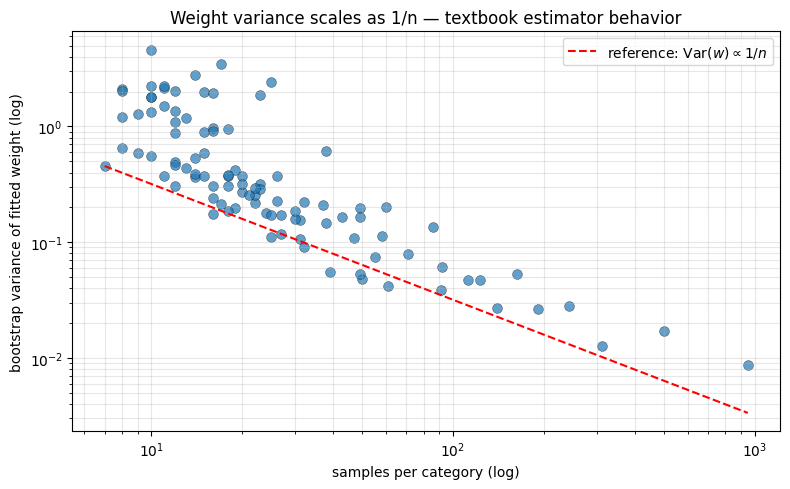

In [13]:
fig, ax = plt.subplots(figsize=(8, 5))
mask = (counts.reindex(np.arange(N_CATS)).values > 0) & np.isfinite(weight_var)
n_c = counts.reindex(np.arange(N_CATS)).values[mask]
v_c = weight_var[mask]

ax.scatter(n_c, v_c, alpha=0.7, s=50, edgecolor='k', linewidth=0.3)
# Reference line: variance ∝ 1 / n
ref_n = np.array([n_c.min(), n_c.max()])
ref_var = v_c[np.argmin(n_c)] * (n_c.min() / ref_n)
ax.plot(ref_n, ref_var, 'r--', lw=1.5, label=r'reference: $\mathrm{Var}(w) \propto 1/n$')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('samples per category (log)')
ax.set_ylabel('bootstrap variance of fitted weight (log)')
ax.set_title('Weight variance scales as 1/n — textbook estimator behavior')
ax.legend()
ax.grid(alpha=0.3, which='both')
plt.tight_layout()
plt.show()


Straight line on a log-log plot with slope $-1$: **weight variance scales as $1/n$**, exactly as first-year statistics predicts. Every rare category is its own tiny overfit model, glued to the rest of the pipeline.

- Trees hide this (they refuse to split on rare categories).
- Linear models will not.
- Deep networks will not.

This is the failure mode that **target encoding** (Ep. 5) was invented to fight and that **embeddings** (Ep. 18) actually fix — by pooling evidence across similar categories through a shared low-dimensional projection.


## Part 4 — The production bug: `handle_unknown`

`OneHotEncoder` is a **fitted** transform. It learns which categories exist at `.fit()` time. If a new category shows up at `.transform()` time — a new user, a new SKU, a new region — the default is to raise.


In [14]:
enc = OneHotEncoder(handle_unknown='error', sparse_output=False)
enc.fit(np.array([['A'], ['B'], ['C']]))

try:
    enc.transform(np.array([['A'], ['D']]))
except ValueError as e:
    print(f'ValueError: {e}')


ValueError: Found unknown categories [np.str_('D')] in column 0 during transform


In production. At 2 AM. On the day the marketing team adds a new region.

Two safer options:


In [15]:
# Option 1: silently zero out the row's one-hot entry.
enc_ignore = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
enc_ignore.fit(np.array([['A'], ['B'], ['C']]))
out = enc_ignore.transform(np.array([['A'], ['D']]))
print("handle_unknown='ignore':")
print(out)
print('  → new category "D" becomes an all-zero row; the model effectively sees "no category"\n')

# Option 2: bucket rare / unseen categories into a synthetic "infrequent" bin.
data = np.array([['A']]*20 + [['B']]*20 + [['C']]*20 + [['D']]*2 + [['E']]*2)
enc_infreq = OneHotEncoder(
    handle_unknown='infrequent_if_exist',
    min_frequency=5,
    sparse_output=False,
)
enc_infreq.fit(data)
out = enc_infreq.transform(np.array([['A'], ['D'], ['Z']]))  # 'Z' unseen
print("handle_unknown='infrequent_if_exist' with min_frequency=5:")
print('  categories after fit:', enc_infreq.categories_[0].tolist())
print('  columns after fit   :', enc_infreq.get_feature_names_out().tolist())
print('  transform of [A, D, Z]:')
print(out)
print('  → both D (seen but rare) and Z (unseen) route to the "infrequent" bucket')


handle_unknown='ignore':
[[1. 0. 0.]
 [0. 0. 0.]]
  → new category "D" becomes an all-zero row; the model effectively sees "no category"

handle_unknown='infrequent_if_exist' with min_frequency=5:
  categories after fit: ['A', 'B', 'C', 'D', 'E']
  columns after fit   : ['x0_A', 'x0_B', 'x0_C', 'x0_infrequent_sklearn']
  transform of [A, D, Z]:
[[1. 0. 0. 0.]
 [0. 0. 0. 1.]
 [0. 0. 0. 1.]]
  → both D (seen but rare) and Z (unseen) route to the "infrequent" bucket


**Rule:** for any pipeline that goes to production, pick `handle_unknown='ignore'` (fast, silent, means "no signal") or `handle_unknown='infrequent_if_exist'` with `min_frequency` (buckets rare and unseen categories together — usually the right choice).

**Callback to Ep. 3:** the encoder's decision about *which* categories are rare enough to bucket looks at the training data. It must be re-fit inside the CV loop, not before the split. Use a `Pipeline`. The one-liner rule from Ep. 3 does not clock out at the categorical encoder.


## Part 5 — The connective insight

Ep. 3 introduced an axis for reducing feature *count*:

> hard feature selection → L1 regularization → learned embeddings

Ep. 4's version, for categorical *encoding*:

| Encoding | Similarity structure | Parameters | Where the reduction lives |
|---|---|---|---|
| **One-hot** | None. Categories mutually orthogonal ($\sqrt{2}$ apart). | Zero. | Nowhere — this is the un-reduced baseline. |
| **Target encoding** *(Ep. 5)* | Supervised — based on mean `y` per category. Two categories with similar `y` get similar codes. | One scalar per category. | Pre-model, single-value collapse. |
| **Learned embedding** *(Ep. 18)* | Learned jointly with the downstream task. | $K \times d$ where $d \ll K$. | Inside the model architecture. |

**One-hot refuses to guess** at similarity. **Target encoding cheats** — it uses the labels. **Embeddings learn** the similarity from the data and the task at the same time.

Everything from Ep. 5 onward is a story about how to buy back the similarity structure that one-hot threw away — in different currencies (labels, matrix factorizations, gradients, transformers), at different scales, with different trade-offs.

**A basis is a choice.** One-hot picks the worst possible basis for high-cardinality categoricals — orthogonal, uninformative, memory-catastrophic — because it's the easiest to construct without data. Every technique after this episode buys similarity structure back.


## Recap

1. **Geometrically, one-hot puts every category at the same distance from every other category.** Toyota, Honda, Ferrari all $\sqrt{2}$ apart. The encoding erases similarity structure by construction.
2. **When one-hot is correct:** low cardinality, nominal categories, adequate samples per category. Weekdays. States. Blood types.
3. **When one-hot silently kills you:** high cardinality (memory), rare categories (per-category weights become pure noise, variance $\propto 1/n$), unseen categories at inference (`handle_unknown`).
4. **Embeddings exist because of point 3.** Give up orthogonality, buy back a learned similarity structure. Same axis Ep. 3 drew — hard selection → soft shrinkage → dense learned projection.

**Next episode:** beyond one-hot. Target encoding — the technique that fixes one-hot's similarity blindness by injecting information from the labels — and the leakage bug that comes for free with it.
